In [25]:
import pandas as pd
import numpy as np

# Load the original files with the correct encoding
hosp_file = '../Input_Files/Hospital_General_Information.csv'
bill_file = '../Input_Files/Medicare_IP_Hospitals_by_Provider_and_Service_2023.csv'

print("🔄 Loading data... this might take a moment.")

# FIX: Added encoding='latin-1' to handle special characters
hosp_df = pd.read_csv(hosp_file, encoding='latin-1')
bill_df = pd.read_csv(bill_file, encoding='latin-1')

print("✅ Files loaded successfully!")

# --- Rest of your script continues here ---
# 1. Create dim_hospitals
print("📑 Creating dim_hospitals...")
hospitals = hosp_df[['Facility ID', 'Facility Name', 'Hospital Type', 'Hospital Ownership', 'Emergency Services', 'Hospital overall rating']].copy()
hospitals.columns = ['facility_id', 'hospital_name', 'type', 'ownership', 'emergency_services', 'rating']
hospitals['rating'] = pd.to_numeric(hospitals['rating'].replace('Not Available', np.nan))
hospitals['facility_id'] = hospitals['facility_id'].astype(str).str.zfill(6)
hospitals.to_csv('../Output_files/hospitals.csv', index=False)

# 2. Create dim_locations
print("📍 Creating dim_locations...")
locations = hosp_df[['Facility ID', 'Address', 'City/Town', 'State', 'ZIP Code', 'County/Parish']].copy()
locations.columns = ['facility_id', 'address', 'city', 'state', 'zip', 'county']
locations['facility_id'] = locations['facility_id'].astype(str).str.zfill(6)
locations.to_csv('../Output_files/locations.csv', index=False)

# 3. Create ref_drg
print("🩺 Creating ref_drg...")
ref_drg = bill_df[['DRG_Cd', 'DRG_Desc']].drop_duplicates()
ref_drg.columns = ['drg_code', 'drg_description']
ref_drg.to_csv('../Output_files/ref_drg.csv', index=False)

# 4. Create fact_billing
print("💰 Creating fact_billing...")
billing = bill_df[['Rndrng_Prvdr_CCN', 'DRG_Cd', 'Tot_Dschrgs', 'Avg_Submtd_Cvrd_Chrg', 'Avg_Tot_Pymt_Amt', 'Avg_Mdcr_Pymt_Amt']].copy()
billing.columns = ['facility_id', 'drg_code', 'total_discharges', 'avg_submitted_charges', 'avg_total_payment', 'avg_medicare_payment']
billing['facility_id'] = billing['facility_id'].astype(str).str.zfill(6)
billing.to_csv('../Output_files/billing.csv', index=False)

print("🚀 Done! All 4 files are ready in your folder.")

🔄 Loading data... this might take a moment.
✅ Files loaded successfully!
📑 Creating dim_hospitals...
📍 Creating dim_locations...
🩺 Creating ref_drg...
💰 Creating fact_billing...
🚀 Done! All 4 files are ready in your folder.


Buisness Questions:

In [10]:
# 1. Focus only on Heart Failure (DRG 291)
# Tip: Check if your data uses '291' or '291 - HEART FAILURE & SHOCK...'
particular_drg = '291' 
billing['drg_code'] = billing['drg_code'].astype(str)
billing = billing[billing['drg_code'].str.contains(particular_drg)].copy()

print(f"📊 Dataset filtered! Now analyzing {len(bill_df)} records for Heart Failure only.")

📊 Dataset filtered! Now analyzing 146427 records for Heart Failure only.


In [11]:
# 4. Create fact_billing with State-Average Analysis
print("💰 Calculating Price vs. State Average...")

# Step A: Create a temporary map of Facility ID to State
# We need this because 'billing' doesn't have a 'state' column yet
state_lookup = locations[['facility_id', 'state']]

# Step B: Merge state into the billing dataframe
billing_with_state = billing.merge(state_lookup, on='facility_id', how='left')

# Step C: The "Window Function" (AVG() OVER(PARTITION BY state, drg_code))
# We group by State AND Procedure to ensure we are comparing apples to apples
billing_with_state['state_drg_avg'] = billing_with_state.groupby(['state', 'drg_code'])['avg_total_payment'].transform('mean')

# Step D: Calculate the Percentage (Hypothesis: > 150% of average)
billing_with_state['pct_of_state_avg'] = (billing_with_state['avg_total_payment'] / billing_with_state['state_drg_avg']) * 100

# Save the enriched fact table
billing_with_state.to_csv('../Output_files/billing_analysis.csv', index=False)

# Quick Test: Find the hospitals charging 50% more than their state average
outliers = billing_with_state[billing_with_state['pct_of_state_avg'] > 150]
print(f"✅ Found {len(outliers)} instances where price is > 50% above state average.")

💰 Calculating Price vs. State Average...
✅ Found 104 instances where price is > 50% above state average.


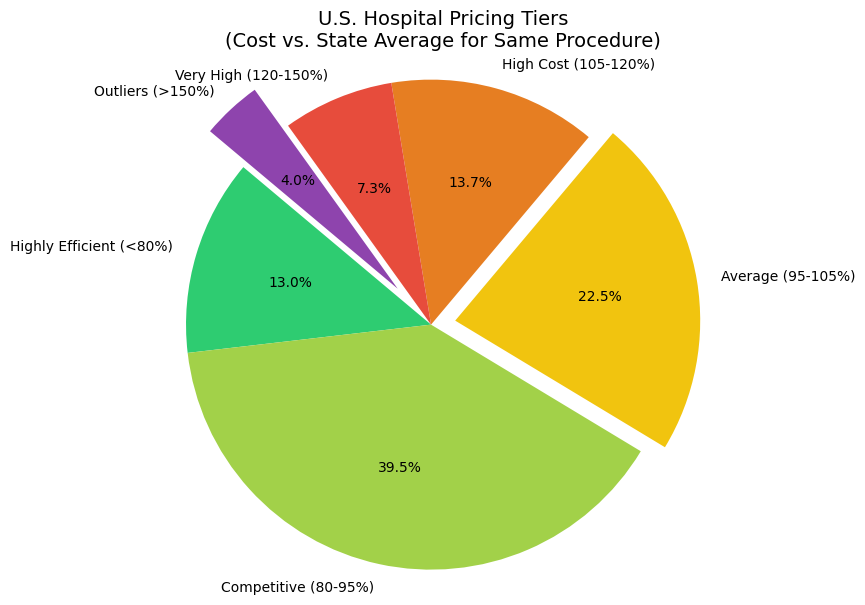

In [13]:
import matplotlib.pyplot as plt

# 1. Merge and Calculate (from previous step)
state_lookup = locations[['facility_id', 'state']]
billing_analysis = billing.merge(state_lookup, on='facility_id', how='left')
billing_analysis['state_drg_avg'] = billing_analysis.groupby(['state', 'drg_code'])['avg_total_payment'].transform('mean')
billing_analysis['pct_of_state_avg'] = (billing_analysis['avg_total_payment'] / billing_analysis['state_drg_avg']) * 100

# 2. Define the 6 Price Groups (Bins)
# These represent how much they charge vs. the state average
bins = [0, 80, 95, 105, 120, 150, 1000] 
labels = [
    'Highly Efficient (<80%)', 
    'Competitive (80-95%)', 
    'Average (95-105%)', 
    'High Cost (105-120%)', 
    'Very High (120-150%)', 
    'Outliers (>150%)'
]

# 3. Categorize every record into a group
billing_analysis['price_tier'] = pd.cut(billing_analysis['pct_of_state_avg'], bins=bins, labels=labels)

# 4. Create the Pie Chart Data
tier_counts = billing_analysis['price_tier'].value_counts().sort_index()

# 5. Plotting the results
plt.figure(figsize=(10, 7))
colors = ['#2ecc71', '#a2d149', '#f1c40f', '#e67e22', '#e74c3c', '#8e44ad'] # Green to Purple
plt.pie(tier_counts, labels=tier_counts.index, autopct='%1.1f%%', startangle=140, colors=colors, explode=(0,0,0.1,0,0,0.2))

plt.title('U.S. Hospital Pricing Tiers\n(Cost vs. State Average for Same Procedure)', fontsize=14)
plt.axis('equal') 
plt.show()

3. The "High Quality, Low Cost" Filter (CTE)
Hypothesis: There are "Hidden Gem" hospitals that have a 5-star rating but cost less than the national average.
•	SQL Feature: WITH (CTE).
•	Why use it: CTEs make your code readable. You define your "Average" once at the top, then use it in your main query below.


In [14]:
# 1. Define the 'CTE' - Calculate the National Average for each procedure
# This is like the 'WITH' block in SQL
national_avg = billing.groupby('drg_code')['avg_total_payment'].mean().reset_index()
national_avg.columns = ['drg_code', 'natl_avg_payment']

# 2. Merge the Average back to the main Billing data
billing_with_avg = billing.merge(national_avg, on='drg_code')

# 3. Join with Hospitals to get the Star Ratings
gems_df = billing_with_avg.merge(hospitals[['facility_id', 'hospital_name', 'rating']], on='facility_id')

# 4. Apply the "Hidden Gem" Filter
# Criteria: 5-Star Rating AND Cost < National Average
hidden_gems = gems_df[
    (gems_df['rating'] == 5.0) & 
    (gems_df['avg_total_payment'] < gems_df['natl_avg_payment'])
]

print(f"💎 Found {hidden_gems['hospital_name'].nunique()} 'Hidden Gem' hospitals!")

💎 Found 136 'Hidden Gem' hospitals!


4. Ownership Benchmarking (CTE + Window Function)
Hypothesis: Proprietary (For-Profit) hospitals consistently have lower ratings than Government hospitals in the same region.
•	SQL Feature: CTE and AVG() OVER().
•	Why use it: It creates a "Benchmark." You can see the hospital's rating side-by-side with the average rating for its ownership type.


In [18]:
# 1. Prepare the Benchmark Table (The "CTE" equivalent)
# We need to link hospital info (ownership/rating) with location (state)
ownership_df = hospitals.merge(locations[['facility_id', 'state']], on='facility_id')

# 2. Calculate Benchmarks (The "Window Function" equivalent)
# Calculate the Average Rating for each State and Ownership type
ownership_df['state_ownership_avg'] = ownership_df.groupby( 'ownership')['rating'].transform('mean')

# 3. Final Summary for Presentation
# Let's compare Government vs. Proprietary (For-Profit) across the whole dataset
summary = ownership_df.groupby( 'ownership')['rating'].mean().sort_values(ascending=False)

print("📊 National Average Rating by Ownership Type:")
print(summary)

📊 National Average Rating by Ownership Type:
ownership
Veterans Health Administration                 4.203540
Physician                                      3.315789
Voluntary non-profit - Church                  3.200980
Voluntary non-profit - Other                   3.188034
Voluntary non-profit - Private                 3.175620
Government - Federal                           3.000000
Tribal                                         3.000000
Government - Hospital District or Authority    2.827778
Government - State                             2.777778
Government - Local                             2.755102
Proprietary                                    2.633475
Department of Defense                               NaN
Name: rating, dtype: float64


simple questionf:
1. The "Top 10" List
Question: Which 10 hospitals handled the most "Heart Failure" (DRG 291) patients in the entire country?
•	Hypothesis: Large university or government-owned hospitals will have the highest patient volume (discharges).


In [ ]:
# 1. Filter for Heart Failure (if not already done)
particular_drg = '291'
billing_hf = billing[billing['drg_code'].astype(str).str.contains(particular_drg)].copy()

# 2. Merge with Hospital names and ownership for the "Story"
volume_analysis = billing_hf.merge(hospitals[['facility_id', 'hospital_name', 'ownership', 'rating']], on='facility_id')

# 3. Sort by Total Discharges
top_10_volume = volume_analysis.sort_values(by='total_discharges', ascending=False).head(10)

# 4. Display the "Heavy Hitters"
print(f"🏥 Top 10 High-Volume Centers for Heart Failure (DRG {particular_drg}):")
print(top_10_volume[['hospital_name', 'total_discharges', 'rating']])

🏥 Top 10 High-Volume Centers for Heart Failure (DRG 291):
                                        hospital_name  total_discharges  \
469                              ADVENTHEALTH ORLANDO              1315   
1574                   NEW YORK-PRESBYTERIAN HOSPITAL              1022   
454                               CHRISTIANA HOSPITAL               856   
1987                           LEHIGH VALLEY HOSPITAL               800   
1618                            NYU LANGONE HOSPITALS               791   
2256                               METHODIST HOSPITAL               785   
1154                       SOUTHCOAST HOSPITALS GROUP               718   
1601           ST FRANCIS HOSPITAL - THE HEART CENTER               695   
1100  LUMINIS HEALTH ANNE ARUNDEL MEDICAL CENTER, INC               670   
1155                          BAYSTATE MEDICAL CENTER               669   

      rating  
469      3.0  
1574     5.0  
454      4.0  
1987     4.0  
1618     5.0  
2256     3.0  
1154     4.

In [31]:
# 1. Filter for Heart Failure and merge State data
particular_drg = '291'
state_billing = billing.merge(locations[['facility_id', 'state']], on='facility_id')

# 2. Group by State to find the averages
# We count hospitals per state to ensure the data is significant
state_ranking = state_billing.groupby('state').agg(
    avg_payment=('avg_total_payment', 'mean'),
    hospital_count=('facility_id', 'count')
).reset_index()

# 3. Get the Top 10 Most Expensive States
top_10_states = state_ranking.sort_values(by='avg_payment', ascending=False).head(10)

# 4. Round values for the chart
top_10_states['avg_payment'] = top_10_states['avg_payment'].round(2)

print("📊 Top 10 Most Expensive States for Heart Failure Treatment:")
print(top_10_states)

📊 Top 10 Most Expensive States for Heart Failure Treatment:
   state  avg_payment  hospital_count
7     DC     31060.18             503
0     AK     25169.91             316
11    HI     25145.14             363
4     CA     24438.94           12896
20    MD     24433.35            3518
34    NY     23583.19            8306
37    OR     22611.45            1327
23    MN     21557.08            2245
6     CT     20760.53            1578
44    UT     20516.83             795


5. The "Medicare Gap"
Question: For each procedure, what is the average difference between what the hospital billed (avg_submitted_charges) and what Medicare actually paid (avg_total_payment)?
•	Hypothesis: Hospitals bill significantly more (often 3x or 4x more) than the amount they actually receive from Medicare.
•	SQL Skills: Basic Math in SELECT, JOIN, GROUP BY.

In [32]:
# 1. Filter for Heart Failure (DRG 291)
particular_drg = '291'
billing_hf = billing[billing['drg_code'].astype(str).str.contains(particular_drg)].copy()

# 2. Calculate the Math (The "Calculated Columns")
# Difference in dollars
billing_hf['billing_gap'] = billing_hf['avg_submitted_charges'] - billing_hf['avg_total_payment']

# The "Multiple" (Sticker Price / Paid Price)
billing_hf['markup_multiple'] = (billing_hf['avg_submitted_charges'] / billing_hf['avg_total_payment']).round(2)

# 3. Aggregate for the National Story
national_stats = billing_hf.agg({
    'avg_submitted_charges': 'mean',
    'avg_total_payment': 'mean',
    'billing_gap': 'mean',
    'markup_multiple': 'mean'
})

print(f"🏥 National Billing Gap for Heart Failure (DRG {particular_drg}):")
print(f"Average Sticker Price: ${national_stats['avg_submitted_charges']:,.2f}")
print(f"Average Actual Payment: ${national_stats['avg_total_payment']:,.2f}")
print(f"Average Write-off: ${national_stats['billing_gap']:,.2f}")
print(f"Typical Markup Multiple: {national_stats['markup_multiple']:.2f}x")

🏥 National Billing Gap for Heart Failure (DRG 291):
Average Sticker Price: $49,752.10
Average Actual Payment: $11,548.46
Average Write-off: $38,203.64
Typical Markup Multiple: 4.43x
